In [1]:
from collections.abc import Mapping
from pathlib import Path
from typing import Any

import numpy as np
from dataeval.data import Indices, Limit, Shuffle, View
from datamaite import load_ic
from maite_datasets.image_classification import MilitaryVehicles, Ships
from numpy.typing import NDArray

data_root = Path("./data")
MilitaryVehicles(root=data_root, image_set="base", download=True)
MilitaryVehicles(root=data_root, image_set="train", as_datamaite=True)

vehicles_raw = load_ic(data_root / "militaryvehicles_datamaite_train" / "train", dataset_format="huggingface_vision")

# The loader groups samples by class folder, so raw index order is alphabetical by class.
# `Shuffle` imposes one seeded sequence, which is what keeps the reference and incoming
# slices below from being drawn from different corners of the label space. `View` is the
# same machinery a `ViewConfig` drives from the pipeline config; `resolve_indices()` hands
# back the shuffled source indices so each slice can be cut with `Indices`.
_order = View(vehicles_raw, [Shuffle(seed=42), Limit(2500)]).resolve_indices()

# Reference: the first 2 000 frames, unmodified
ref_maite = View(vehicles_raw, [Indices(_order[:2000])])

print(f"Reference: {len(ref_maite)} frames")
print(f"Sample shape: image={ref_maite[0][0].shape}, dtype={ref_maite[0][0].dtype}")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reference: 2000 frames
Sample shape: image=(3, 170, 297), dtype=uint8


In [2]:
ships = Ships(root=data_root, download=True)
print(f"Foreign source: {len(ships)} satellite frames, shape {ships[0][0].shape}")


class MisalignedImages:
    """Keeps each datum's annotation and replaces only its pixels.

    Parameters
    ----------
    dataset
        A MAITE-compatible dataset returning (image, target, metadata) tuples.
    foreign
        The dataset supplying replacement imagery.
    start, count
        The contiguous run of positions whose images are replaced.
    """

    def __init__(self, dataset: Any, foreign: Any, start: int, count: int) -> None:
        self._dataset = dataset
        self._foreign = foreign
        self._span = range(start, start + count)
        self.metadata = {"id": "misaligned_images", "original_metadata": dataset.metadata}

    def __len__(self) -> int:
        return len(self._dataset)

    def swapped(self, index: int) -> bool:
        """Whether this position carries foreign imagery."""
        return index in self._span

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, metadata = self._dataset[index]
        if index in self._span:
            image = np.asarray(self._foreign[(index - self._span.start) % len(self._foreign)][0])
        return image, target, metadata


# Incoming: the next 500 frames, with positions 200-299 carrying ships imagery
incoming_maite = View(vehicles_raw, [Indices(_order[2000:2500])])
incoming_dataset = MisalignedImages(incoming_maite, ships, start=200, count=100)

n_swapped = sum(1 for i in range(len(incoming_dataset)) if incoming_dataset.swapped(i))
print(f"Incoming: {len(incoming_dataset)} frames")
print(f"  In-distribution (vehicles):        {len(incoming_dataset) - n_swapped}")
print(f"  Out-of-distribution (ships under vehicle labels): {n_swapped}")

Foreign source: 4000 satellite frames, shape (3, 80, 80)
Incoming: 500 frames
  In-distribution (vehicles):        400
  Out-of-distribution (ships under vehicle labels): 100


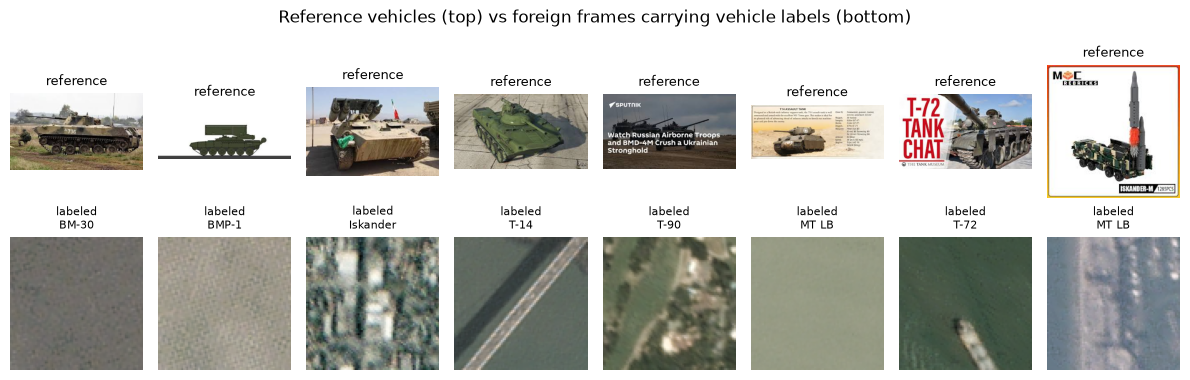

In [3]:
import matplotlib.pyplot as plt

index2label = vehicles_raw.metadata.get("index2label", {})
fig, axes = plt.subplots(2, 8, figsize=(12, 4))

for col in range(8):
    img_arr = np.transpose(np.asarray(ref_maite[col][0]), (1, 2, 0))  # CHW -> HWC
    axes[0, col].imshow(img_arr)
    axes[0, col].set_title("reference", fontsize=9)
    axes[0, col].axis("off")

swapped_indices = [i for i in range(len(incoming_dataset)) if incoming_dataset.swapped(i)]
for col in range(8):
    idx = swapped_indices[col * 4]
    image, target, _ = incoming_dataset[idx]
    img_arr = np.transpose(np.asarray(image), (1, 2, 0))  # CHW -> HWC
    axes[1, col].imshow(img_arr)
    axes[1, col].set_title(f"labeled\n{index2label[int(np.argmax(target))]}", fontsize=8)
    axes[1, col].axis("off")

fig.suptitle("Reference vehicles (top) vs foreign frames carrying vehicle labels (bottom)", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
import torch
import torchvision

from dataeval_flow.config import (
    DatasetProtocolConfig,
    PipelineConfig,
    PreprocessorConfig,
    SourceConfig,
    TorchExtractorConfig,
)
from dataeval_flow.preprocessing import PreprocessingStep

# Cache weights locally for TorchExtractorConfig
model_dir = Path("./models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "resnet18.pt"
if not model_path.exists():
    torch.save(torchvision.models.resnet18(weights="IMAGENET1K_V1").eval(), model_path)

# --- Datasets (in-memory via DatasetProtocolConfig) ---
ref_config = DatasetProtocolConfig(
    name="reference",
    format="maite",
    dataset=ref_maite,
)

incoming_config = DatasetProtocolConfig(
    name="incoming",
    format="maite",
    dataset=incoming_dataset,
)

# --- Extractor ---
preprocessor_config = PreprocessorConfig(
    name="imagenet",
    steps=[
        PreprocessingStep(step="Resize", params={"size": [224, 224], "antialias": True}),
        PreprocessingStep(step="ToDtype", params={"dtype": "float32", "scale": True}),
        PreprocessingStep(
            step="Normalize",
            params={"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
        ),
    ],
)

extractor_config = TorchExtractorConfig(
    name="resnet18",
    model_path=str(model_path),
    layer_name="avgpool",
    preprocessor="imagenet",
    batch_size=32,
)

In [5]:
from dataeval_flow.config import OODDetectionTaskConfig, OODDetectionWorkflowConfig
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.ood.params import (
    OODDetectorDomainClassifier,
    OODDetectorKNeighbors,
    OODHealthThresholds,
)

task = OODDetectionTaskConfig(
    name="vehicles-ood-check",
    workflow="vehicles-ood",
    sources=["ref_src", "inc_src"],
    extractor="resnet18",
)

config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    sources=[
        SourceConfig(name="ref_src", dataset="reference"),
        SourceConfig(name="inc_src", dataset="incoming"),
    ],
    preprocessors=[preprocessor_config],
    extractors=[extractor_config],
    workflows=[
        OODDetectionWorkflowConfig(
            name="vehicles-ood",
            detectors=[
                OODDetectorKNeighbors(
                    k=10,
                    distance_metric="cosine",
                    threshold_perc=99.0,
                ),
                OODDetectorDomainClassifier(
                    n_folds=3,
                    n_repeats=3,
                    threshold_perc=99.0,
                ),
            ],
            health_thresholds=OODHealthThresholds(
                ood_pct_warning=5.0,  # warn if >5% of samples are OOD
                ood_pct_info=1.0,  # info if >1% of samples are OOD
            ),
            metadata_insights=True,
            max_ood_insights=50,
        ),
    ],
)

In [6]:
result = run_task(task, config, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/binning.py:438: UserWarning: `height` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  factor_info = metadata.factor_info


In [7]:
print(result.report())


  OOD DETECTION COMPLETE. REFERENCE: 2000 ITEMS, TEST: 500 ITEMS.
  Timestamp:    2026-09-19T01:52:22.053619+00:00
  Duration:     37.06s
  Source:       ref_src (reference)
                inc_src (incoming)
  Model:        resnet18 (torch)
  Preprocessor: imagenet
--------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (threshold_perc=99.0) ...................................   [!!]
  Domain Classifier (n_folds=3, n_repeats=3, threshold_perc=99.0) .....   [!!]
  Aggregate OOD (all detectors agree) .................................   [!!]
  Unique OOD Samples (single-detector only) ...........................   [..]
  OOD Factor Predictors ...............................................   [..]
  OOD Sample Metadata Deviations ......................................   [..]

  Health: 3 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (THRESHOLD_PERC=99.0)
  K-Neighbors (threshold_perc=99.0): 103/500 samples OOD (20.6%)

In [8]:
raw = result.data.raw

print(f"Reference size:  {raw.reference_size}")
print(f"Test size:       {raw.test_size}")
print(f"OOD samples:     {len(raw.ood_indices)} (union across all detectors)")
print()

for method, det_result in raw.detectors.items():
    print(f"-- {method} --")
    print(f"  OOD count:     {det_result['ood_count']} / {det_result['total_count']}")
    print(f"  OOD percentage: {det_result['ood_percentage']:.1f}%")
    print(f"  Threshold:     {det_result['threshold_score']:.4f}")
    print()

Reference size:  2000
Test size:       500
OOD samples:     103 (union across all detectors)

-- kneighbors --
  OOD count:     103 / 500
  OOD percentage: 20.6%
  Threshold:     0.3012

-- domain_classifier --
  OOD count:     96 / 500
  OOD percentage: 19.2%
  Threshold:     0.5259



In [9]:
truth = [incoming_dataset.swapped(i) for i in range(len(incoming_dataset))]
planted = sum(truth)

for method, det_result in raw.detectors.items():
    flagged = [sample["index"] for sample in det_result.get("samples", []) if sample.get("is_ood")]
    hits = sum(1 for i in flagged if truth[i])
    recall = hits / planted * 100 if planted else 0.0
    precision = hits / len(flagged) * 100 if flagged else 0.0
    print(
        f"{method:>18}: flagged {len(flagged):>3} of {planted} planted -- recall {recall:.0f}%, precision {precision:.0f}%"
    )

        kneighbors: flagged 103 of 100 planted -- recall 100%, precision 97%
 domain_classifier: flagged  96 of 100 planted -- recall 96%, precision 100%


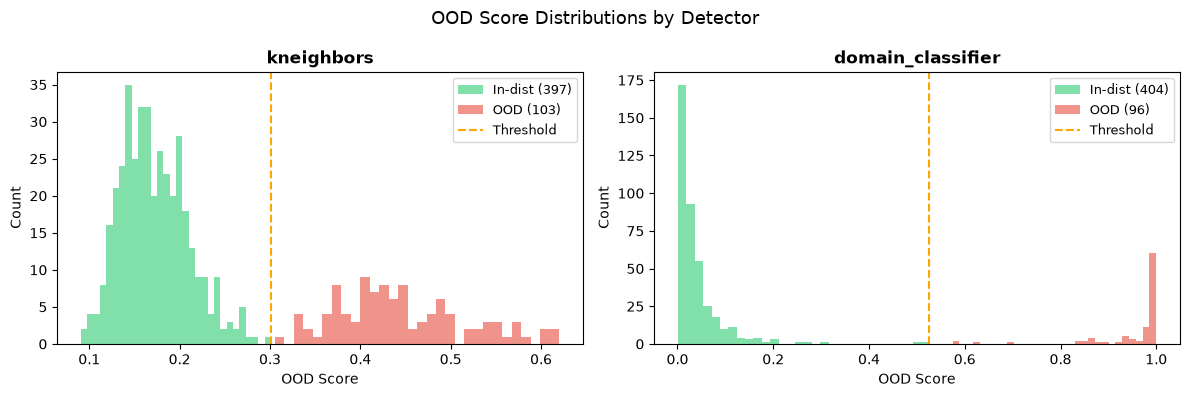

In [10]:
fig, axes = plt.subplots(1, len(raw.detectors), figsize=(6 * len(raw.detectors), 4))
if len(raw.detectors) == 1:
    axes = [axes]

ood_set = set(raw.ood_indices)

for ax, (method, det_result) in zip(axes, raw.detectors.items(), strict=True):
    samples = det_result.get("samples", [])
    if not samples:
        continue

    in_scores = [s["score"] for s in samples if not s["is_ood"]]
    ood_scores = [s["score"] for s in samples if s["is_ood"]]

    ax.hist(in_scores, bins=30, alpha=0.6, label=f"In-dist ({len(in_scores)})", color="#2ecc71")
    ax.hist(ood_scores, bins=30, alpha=0.6, label=f"OOD ({len(ood_scores)})", color="#e74c3c")
    ax.axvline(x=det_result["threshold_score"], color="orange", linestyle="--", label="Threshold")
    ax.set_xlabel("OOD Score")
    ax.set_ylabel("Count")
    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("OOD Score Distributions by Detector", fontsize=13)
plt.tight_layout()
plt.show()

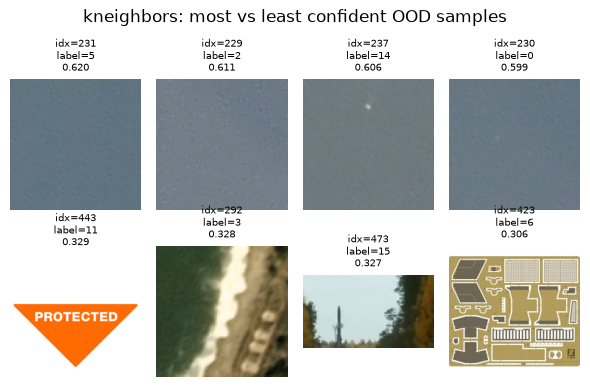

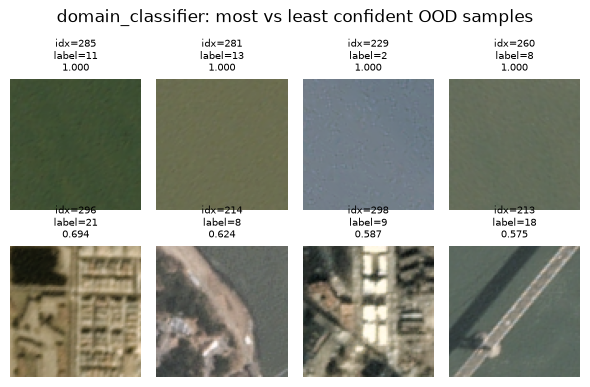

In [11]:
cols = 4

for method, det_result in raw.detectors.items():
    samples = det_result.get("samples", [])
    ood_samples = sorted(
        [(s["index"], s["score"]) for s in samples if s["is_ood"]],
        key=lambda x: -x[1],
    )
    if not ood_samples:
        continue

    top = ood_samples[:cols]
    bottom = ood_samples[-cols:]

    fig, axes = plt.subplots(2, cols, figsize=(1.5 * cols, 4))

    for row_idx, (row_label, row_items) in enumerate([("Top 4 (most OOD)", top), ("Bottom 4 (least OOD)", bottom)]):
        for col, (idx, score) in enumerate(row_items):
            img_data, target, _ = incoming_dataset[idx]
            img_arr = np.asarray(img_data)
            if img_arr.ndim == 3 and img_arr.shape[0] in (1, 3):
                img_arr = img_arr.squeeze(0) if img_arr.shape[0] == 1 else np.moveaxis(img_arr, 0, -1)
            axes[row_idx, col].imshow(img_arr, cmap="gray")
            label = int(np.argmax(target)) if np.asarray(target).ndim > 0 else int(target)
            axes[row_idx, col].set_title(f"idx={idx}\nlabel={label}\n{score:.3f}", fontsize=7)
            axes[row_idx, col].axis("off")
        for col in range(len(row_items), cols):
            axes[row_idx, col].axis("off")
        axes[row_idx, 0].set_ylabel(row_label, fontsize=8)

    fig.suptitle(f"{method}: most vs least confident OOD samples", fontsize=12)
    plt.tight_layout()
    plt.show()

In [12]:
if raw.factor_predictors:
    print("Factor Predictors (mutual information with OOD status):")
    print("-" * 50)
    for factor, mi in raw.factor_predictors.items():
        bar = "#" * int(mi * 20)
        print(f"  {factor:20s}  {mi:.4f} bits  {bar}")
    print()

if raw.factor_deviations:
    print(f"Factor Deviations (top {min(10, len(raw.factor_deviations))} OOD samples):")
    print("-" * 50)
    for dev in raw.factor_deviations[:10]:
        top_factors = list(dev["deviations"].items())[:3]
        factors_str = ", ".join(f"{k}={v:.2f}" for k, v in top_factors)
        print(f"  Sample {dev['index']:4d}: {factors_str}")

Factor Predictors (mutual information with OOD status):
--------------------------------------------------
  f_width               0.9292 bits  ##################
  f_height              0.9279 bits  ##################
  f_size                0.9278 bits  ##################
  f_zeros               0.8056 bits  ################
  f_aspect_ratio        0.6420 bits  ############
  f_sharpness           0.6135 bits  ############
  f_std                 0.6038 bits  ############
  f_var                 0.6019 bits  ############
  f_darkness            0.3733 bits  #######
  f_contrast            0.3212 bits  ######
  f_entropy             0.2808 bits  #####
  f_kurtosis            0.1842 bits  ###
  f_brightness          0.1131 bits  ##
  f_skew                0.1084 bits  ##
  f_mean                0.0950 bits  #
  class_label           0.0456 bits  
  width                 0.0264 bits  
  height                0.0066 bits  

Factor Deviations (top 10 OOD samples):
------------------------

In [13]:
NOISY_CLASSES = [1, 5, 11, 16, 23]


class NoisyClasses:
    """Adds heavy sensor noise to frames of the named classes."""

    def __init__(self, dataset: Any, classes: list[int], sigma: float = 60.0) -> None:
        self._dataset = dataset
        self._classes = set(classes)
        self._sigma = sigma
        self._rng = np.random.default_rng(0)
        self.metadata = {"id": "noisy_classes", "original_metadata": dataset.metadata}

    def __len__(self) -> int:
        return len(self._dataset)

    def corrupted(self, index: int) -> bool:
        return int(np.argmax(self._dataset[index][1])) in self._classes

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, metadata = self._dataset[index]
        if int(np.argmax(target)) in self._classes:
            noise = self._rng.normal(0, self._sigma, np.asarray(image).shape)
            image = np.clip(np.asarray(image).astype(np.int16) + noise, 0, 255).astype(np.asarray(image).dtype)
        return image, target, metadata


noisy_dataset = NoisyClasses(View(vehicles_raw, [Indices(_order[2000:2500])]), NOISY_CLASSES)
print(f"Corrupting: {[index2label[c] for c in NOISY_CLASSES]}")

noisy_task = OODDetectionTaskConfig(
    name="vehicles-ood-noise",
    workflow="vehicles-ood",
    sources=["ref_src", "noisy_src"],
    extractor="resnet18",
)
noisy_config = config.model_copy(
    update={
        "datasets": [ref_config, DatasetProtocolConfig(name="noisy", format="maite", dataset=noisy_dataset)],
        "sources": [
            SourceConfig(name="ref_src", dataset="reference"),
            SourceConfig(name="noisy_src", dataset="noisy"),
        ],
        "tasks": [noisy_task],
    }
)

noisy_result = run_task(noisy_task, noisy_config, cache_dir=Path("./cache"))

Corrupting: ['30N6E', 'BMP-2', 'D-30', 'T-14', 'TOS-1']


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/binning.py:438: UserWarning: `height` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  factor_info = metadata.factor_info


In [14]:
noisy_truth = [noisy_dataset.corrupted(i) for i in range(len(noisy_dataset))]
noisy_planted = sum(noisy_truth)

for method, det_result in noisy_result.data.raw.detectors.items():
    flagged = [sample["index"] for sample in det_result.get("samples", []) if sample.get("is_ood")]
    hits = sum(1 for i in flagged if noisy_truth[i])
    recall = hits / noisy_planted * 100 if noisy_planted else 0.0
    precision = hits / len(flagged) * 100 if flagged else 0.0
    print(
        f"{method:>18}: flagged {len(flagged):>3} of {noisy_planted} corrupted -- recall {recall:.0f}%, precision {precision:.0f}%"
    )

        kneighbors: flagged  43 of 93 corrupted -- recall 44%, precision 95%
 domain_classifier: flagged  93 of 93 corrupted -- recall 100%, precision 100%


In [15]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:600] + "\n...")

JSON output: 185701 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-09-19T01:52:22.053619Z",
    "dataset_id": "reference,incoming",
    "label_source": "protocol",
    "model_id": "resnet18 (torch)",
    "preprocessor_id": "imagenet",
    "selection_id": null,
    "source_descriptions": [
      "ref_src (reference)",
      "inc_src (incoming)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "ref_src",
          "dataset": "reference",
          "dataset_config": {
            "name": "reference",
            "format": "maite",
            "version": "1",
            
...
